In [18]:
from __future__ import annotations

from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from datetime import datetime, date
from pathlib import Path
import json
import logging

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100


### logging
biar print auto format


In [19]:
logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
logger = logging.getLogger('log_fx')

testing logging

In [20]:
logger.info('shutdown dalam 5 menit')

[INFO] shutdown dalam 5 menit


In [21]:
class ForexDataError(Exception):
# base
    pass

class InvalidCandleError(ForexDataError):
    pass

class RepositoryNotLoadedError(ForexDataError): # repo diakses sebelum data di load
    pass

class AnalysisError(ForexDataError):
    pass



In [22]:
@dataclass(frozen=True)
class Candle:
    date: datetime
    open: float
    high: float
    low: float
    close: float
    volume: float

    def __post_init__(self) -> None:
        if not isinstance(self.date , datetime):
            raise InvalidCandleError(
                f'tipe data harus date, dapat {type(self.date).__name__}'
            )
    
        for nm in ('open','high','low','close'):
            v = getattr(self , nm) #error handling
            if v <= 0:
                raise InvalidCandleError(f'{nm} harus > 0, v - {v}')
            if self.high < self.low:
                raise InvalidCandleError(f' high {self.high} harus > low {self.low}')
        if not (self.low <= self.open <= self.high):
            raise InvalidCandleError(
                f'open {self.open} harus berada di dalam high dan low'
            )
        if not (self.low <= self.close <= self.high):
            raise InvalidCandleError(
                f'close {self.close} harus berada di dalam high dan low'
            )
        if self.volume < 0:
            raise InvalidCandleError(f'volume harus >= 0')
        
    #helper
    def body_size(self) -> float:
        return abs(self.close - self.open)
    
    def range_size(self) -> float:
        return self.high - self.low
    
    def is_bullish(self) -> bool:
        return self.close > self.open #kalau true = bullish
    
    def daily_return_pct(self) -> float: #return harian
        return (self.close - self.open) / self.open * 100
    
    # magic method
    def __str__(self) -> str:
        tag = 'bull' if self.is_bullish() else 'bear'
        return (
            f'candle({self.date.strftime('%Y-%m-%d')} [{tag}])'
            f'O= {self.open:.5f} H={self.high:.5f}'
            f'L={self.low:.5f} C={self.close:.5f}'
        )
    def __lt__(self, other: "Candle") -> bool: #bandingin candle berdasarkan tanggal
        if not isinstance(other,Candle):
            return NotImplemented
        return self.date < other.date




### testing

In [23]:
assert issubclass(InvalidCandleError, ForexDataError)
assert issubclass(RepositoryNotLoadedError, ForexDataError)
assert issubclass(AnalysisError, ForexDataError)
assert issubclass(ForexDataError, ForexDataError)

## Candle

### bullish candle

In [24]:
c_bull = Candle(date=datetime(2021,1,4),open=1.22340,high=1.23115,low=1.22240,close=1.2290,volume=125000)
assert c_bull.is_bullish() is True, "ini bearish"
assert c_bull.body_size() == (1.2290 - 1.22340)
assert c_bull.range_size() == (1.23115 - 1.22240)
assert c_bull.daily_return_pct() > 0

### bearish candle

In [25]:
c_bear = Candle(date=datetime(2021,1,5), open= 1.23000, high = 1.23100, low = 1.22000, close = 1.22500, volume = 98000)
assert c_bear.is_bullish() == False, "ini bullish"
assert c_bear.daily_return_pct() < 0
print((c_bear.close - c_bear.open) / c_bear.open * 100)



-0.4065040650406418


## testing sorting

In [26]:
candles = [c_bear, c_bull]
sortedCandle = sorted(candles)
assert sortedCandle[0] is c_bull
assert sortedCandle[1] is c_bear

### testing harga negatif

In [27]:
try:
    Candle(date=datetime(2021,1,5), open= -1, high = 1.5, low = 0.5, close = 1., volume = 100)
    raise AssertionError('fail')
except InvalidCandleError:
    pass

### testing high < low

In [28]:
try:
    Candle(date=datetime(2021,1,7), open = 2, high = 2.5, low = 1.5, close = 1, volume = 100)
    raise AssertionError('valid : lempar ke invalidcandleerror')
except InvalidCandleError as e:
    pass
    print(f'output {e}')

output close 1 harus berada di dalam high dan low


In [29]:
try:
    Candle(date=datetime(2021, 1, 8), open=1.0, high=1.5, low=0.8, close=2.0, volume=100.0)
    raise AssertionError("Seharusnya raise InvalidCandleError")
except InvalidCandleError as e:
    pass
    print(f'pesan error {e}')

pesan error close 2.0 harus berada di dalam high dan low


### testing immutability

In [30]:
try:
    c_bull.open = 99.0  
    raise AssertionError("dataclass harusnya gabisa dimutate")
except Exception as e:
    print(f'tes {e}')   

tes cannot assign to field 'open'


### tes magic method

In [31]:
s_bull = str(c_bull)
s_bear = str(c_bear)
assert "2021-01-04" in s_bull and "bull" in s_bull, 'error'
assert "2021-01-05" in s_bear and "bear" in s_bear

In [32]:
logger.info('testing output')

[INFO] testing output


In [33]:
print(f"Bullish sample: {c_bull}")
print(f"Bearish sample: {c_bear}")
print(f"Return pctbull = {c_bull.daily_return_pct():.4f}%")
print(f"Return pct bear = {c_bear.daily_return_pct():.4f}%")
print(f"Range size bull = {c_bull.range_size():.5f}")
print(f"Body size bull = {c_bull.body_size():.5f}")

Bullish sample: candle(2021-01-04 [bull])O= 1.22340 H=1.23115L=1.22240 C=1.22900
Bearish sample: candle(2021-01-05 [bear])O= 1.23000 H=1.23100L=1.22000 C=1.22500
Return pctbull = 0.4577%
Return pct bear = -0.4065%
Range size bull = 0.00875
Body size bull = 0.00560


### CandleRepository
Menerapkan Repository pattern, rincian logic:
1. Load CSV dengan `pandas.read_csv`
2. Parse Tanggal menjadi `datetime`
3. sort by tanggal

In [34]:
class CandleRepository:
    _DATE_FORMAT = '%Y.%m.%d %H:%M'
    _CSV_SEPERATOR = ";"

    def __init__(self) -> None:
        self._candles: list[Candle] = []
        self._file_path: str | None = None
    # load data
    def load_csv(self, file_path: str) -> int:
        path = Path(file_path)
        if not path.exists():
            raise FileNotFoundError(f'file tidak ditemukan : {file_path}')
            
        df = pd.read_csv(path, sep=self._CSV_SEPERATOR)
        logger.info(f"berhasil load {len(df):} baris dari {path.name}")

        #parse kolom date jadi YYYY.MM.DD HH:MM
        df['timestamp'] = pd.to_datetime(df['Date'], format=self._DATE_FORMAT)

        #guard biar data tetap terurut
        df = df.sort_values('timestamp').reset_index(drop=True)
        
        #convert tiap lines jadi 1 candle
        candles: list[Candle] = []
        for _, row in df.iterrows():
            candles.append(
                Candle(
                    date=row['timestamp'].to_pydatetime(),
                    open=float(row['Open']),
                    high=float(row['High']),
                    low=float(row['Low']),
                    close=float(row['Close']),
                    volume=float(row['Volume']),
                )
            )
        
        # save 
        self._candles = candles
        self._file_path = str(path)
        return len(candles)
    
    def _require_loaded(self) -> None:
        if not self._candles:
            raise RepositoryNotLoadedError(
                'gagal load repo'
            )
        
    #getter
    def get_all(self) -> list[Candle]:
        self._require_loaded()
        return list(self._candles)

    def get_by_year(self, year: int) -> list[Candle]:
        self._require_loaded()
        return [c for c in self._candles if c.date.year == year]

    def get_range(self, start: date, end: date) -> list[Candle]:
        self._require_loaded()
        s = start.date() if isinstance(start, datetime) else start
        e = end.date()   if isinstance(end,   datetime) else end
        return [c for c in self._candles if s <= c.date.date() <= e]

    def get_bullish(self) -> list[Candle]: #bullish only close > open
        self._require_loaded()
        return [c for c in self._candles if c.is_bullish()]

    def get_bearish(self) -> list[Candle]:
        self._require_loaded()
        return [c for c in self._candles if not c.is_bullish()]

    def date_range(self) -> tuple[datetime, datetime] | None: # tanggal pertama dan terakhir data, atau none kalau kosong
        if not self._candles:
            return None
        return self._candles[0].date, self._candles[-1].date

    # magic methods
    def __len__(self) -> int:
        return len(self._candles)

    def __repr__(self) -> str:
        n = len(self._candles)
        src = Path(self._file_path).name if self._file_path else "<unloaded>"
        return f"CandleRepository(n={n}, source={src!r})"

### testing buat candlerepo

In [35]:
CSV_PATH = "data/XAU_1d_data.csv"

# test 1 : query sebelum load 
repo_empty = CandleRepository()
try:
    repo_empty.get_all()
    raise AssertionError("Seharusnya raise RepositoryNotLoadedError")
except RepositoryNotLoadedError:
    pass

# test 2 : load_csv berhasil 
repo = CandleRepository()
n_loaded = repo.load_csv(CSV_PATH)
assert n_loaded > 0

# test 3: jumlah candle masuk akal untuk ~21 tahun daily ---
# 21 tahun * 252 trading days/tahun ~= 5.300 candle
assert 5000 <= n_loaded <= 6000, \
    f"Jumlah candle tidak masuk akal: {n_loaded} (harusnya 5000-6000)"

# test 4: tidak ada weekend
weekdays = {c.date.weekday() for c in repo.get_all()}
assert weekdays <= {0, 1, 2, 3, 4}, \
    f"Ada candle weekend di dataset: {weekdays}"

# test 5: __len__
assert len(repo) == n_loaded

# test 6 : semua candle terurut by date
all_candles = repo.get_all()
for i in range(1, len(all_candles)):
    assert all_candles[i - 1].date < all_candles[i].date

# test 7: get_by_year(2020) return jumlah 
candles_2020 = repo.get_by_year(2020)
# 2020 ada 253 trading days di US market
assert 240 < len(candles_2020) < 270, \
    f"Jumlah candle 2020 tidak masuk akal: {len(candles_2020)}"
assert all(c.date.year == 2020 for c in candles_2020)

# test 8: date_range periode 
dr = repo.date_range()
assert dr is not None
first_date, last_date = dr
assert first_date.year == 2004, f"Tahun pertama: {first_date.year}"
assert last_date.year >= 2024, f"Tahun terakhir: {last_date.year}"

# test 9: bullish + bearish = total
n_bull = len(repo.get_bullish())
n_bear = len(repo.get_bearish())
assert n_bull + n_bear == n_loaded

print(f"  Total daily candles : {n_loaded:,}")
print(f"  Periode             : {first_date.date()} s/d {last_date.date()}")
print(f"  Bullish vs Bearish  : {n_bull:,} vs {n_bear:,} (ratio bullish = {n_bull/n_loaded:.1%})")
print(f"  Daily candle 2020   : {len(candles_2020)}")
print(f"  Repo repr           : {repo!r}")
print(f"  Sample first        : {all_candles[0]}")
print(f"  Sample last         : {all_candles[-1]}")

[INFO] berhasil load 5531 baris dari XAU_1d_data.csv


  Total daily candles : 5,531
  Periode             : 2004-06-11 s/d 2026-01-30
  Bullish vs Bearish  : 2,896 vs 2,635 (ratio bullish = 52.4%)
  Daily candle 2020   : 259
  Repo repr           : CandleRepository(n=5531, source='XAU_1d_data.csv')
  Sample first        : candle(2004-06-11 [bull])O= 384.00000 H=384.80000L=382.80000 C=384.10000
  Sample last         : candle(2026-01-30 [bear])O= 5385.09000 H=5450.62000L=4679.69000 C=4889.48000


## Base Analyzer

In [36]:
class BaseAnalyzer(ABC):
    def __init__(self, data: list[Candle], name: str | None = None) -> None:
        if not data:
            raise AnalysisError(
                f"{self.__class__.__name__}: data candle tidak boleh kosong"
            )
        self._data: list[Candle] = list(data) # defensive: simpan sebagai tuple
        self._name: str = name or self.__class__.__name__

    @abstractmethod
    def analyze(self) -> dict:
        pass

    # method yang diwariskan ke semua subclass
    def get_name(self) -> str:
        return self._name

    def get_summary(self) -> dict:
        return {
            "analyzer": self._name,
            "n_candles": len(self._data),
            "first_date": self._data[0].date.strftime("%Y-%m-%d"),
            "last_date": self._data[-1].date.strftime("%Y-%m-%d"),
        }

    def __len__(self) -> int:
        return len(self._data)

    def __repr__(self) -> str:
        return f"{self._name}(n={len(self._data)})"



### Trend Analyzer 
inheritance + polimor

In [37]:
class TrendAnalyzer(BaseAnalyzer): #tren harga, return per tahun & total return periode

    def total_return_pct(self) -> float: # persentase return total dari candle pertama ke terakhir
        first_close = self._data[0].close
        last_close = self._data[-1].close
        return (last_close - first_close) / first_close * 100.0

    def by_year(self) -> dict[int, dict]: #return pertahun
        result: dict[int, dict] = {}
        # grouping candle by year
        years_data: dict[int, list[Candle]] = {}
        for c in self._data:
            years_data.setdefault(c.date.year, []).append(c)

        for year, candles in sorted(years_data.items()):
            start = candles[0].close
            end = candles[-1].close
            result[year] = {
                "start_close": start,
                "end_close": end,
                "return_pct": (end - start) / start * 100.0,
                "n_candles": len(candles),
            }
        return result

    def analyze(self) -> dict:
        by_yr = self.by_year()
        # tahun terbaik & terburuk berdasarkan return
        sorted_yrs = sorted(by_yr.items(), key=lambda kv: kv[1]["return_pct"])
        return {
            **self.get_summary(),
            "total_return_pct": self.total_return_pct(),
            "n_years": len(by_yr),
            "best_year": sorted_yrs[-1][0] if sorted_yrs else None,
            "best_year_return_pct": sorted_yrs[-1][1]["return_pct"] if sorted_yrs else None,
            "worst_year": sorted_yrs[0][0] if sorted_yrs else None,
            "worst_year_return_pct": sorted_yrs[0][1]["return_pct"] if sorted_yrs else None,
            "by_year": by_yr,
        }


print("berhasil membuat subclass")

berhasil membuat subclass


### Volatility analyze

In [38]:
class VolatilityAnalyzer(BaseAnalyzer): #std dev daily returns, range rata-rata

    def _daily_returns(self) -> list[float]: # persentase daily return close-to-close
        out = []
        prev_close = self._data[0].close
        for c in self._data[1:]:
            out.append((c.close - prev_close) / prev_close * 100.0)
            prev_close = c.close
        return out

    def std_returns_pct(self) -> float: # persentase Standar deviasi daily returns (close-to-close)
        returns = self._daily_returns()
        if len(returns) < 2:
            raise AnalysisError("utuh minimal 2 candle untuk std dev")
        s = pd.Series(returns)
        return float(s.std(ddof=1))

    def range_avg(self) -> float: #Range rata-rata candle = mean(high - low)
        return float(sum(c.range_size() for c in self._data) / len(self._data))

    def volatility_by_year(self) -> dict[int, float]: #Std dev daily returns per tahun
        result: dict[int, float] = {}
        years_data: dict[int, list[Candle]] = {}
        for c in self._data:
            years_data.setdefault(c.date.year, []).append(c)
        for year, candles in sorted(years_data.items()):
            if len(candles) < 2:
                continue
            sub_returns = []
            prev = candles[0].close
            for c in candles[1:]:
                sub_returns.append((c.close - prev) / prev * 100.0)
                prev = c.close
            result[year] = float(pd.Series(sub_returns).std(ddof=1))
        return result

    def analyze(self) -> dict:
        vol_by_year = self.volatility_by_year()
        return {
            **self.get_summary(),
            "std_daily_return_pct": self.std_returns_pct(),
            "range_avg": self.range_avg(),
            "volatility_by_year": vol_by_year,
            "most_volatile_year": (
                max(vol_by_year, key=vol_by_year.get) if vol_by_year else None
            ),
            "least_volatile_year": (
                min(vol_by_year, key=vol_by_year.get) if vol_by_year else None
            ),
        }


print("berhasil membuat volatilityanalyzer")

berhasil membuat volatilityanalyzer


### Return Analyze


In [39]:
class ReturnsAnalyzer(BaseAnalyzer): #Analisis daily returns, best/worst day

    def _daily_returns_indexed(self) -> list[tuple[datetime, float]]:
        out = []
        prev_close = self._data[0].close
        for c in self._data[1:]:
            ret = (c.close - prev_close) / prev_close * 100.0
            out.append((c.date, ret))
            prev_close = c.close
        return out

    def best_day(self) -> tuple[datetime, float]: #Hari dengan return tertinggi
        returns = self._daily_returns_indexed()
        if not returns:
            raise AnalysisError("Butuh minimal 2 candle untuk best day")
        return max(returns, key=lambda x: x[1])

    def worst_day(self) -> tuple[datetime, float]: #hari dengan return terendah
        returns = self._daily_returns_indexed()
        if not returns:
            raise AnalysisError("Butuh minimal 2 candle untuk worst day")
        return min(returns, key=lambda x: x[1])

    def returns_distribution(self) -> dict: #statistik
        returns = [r for _, r in self._daily_returns_indexed()]
        s = pd.Series(returns)
        return {
            "n_days": len(returns),
            "mean_pct": float(s.mean()),
            "median_pct": float(s.median()),
            "std_pct": float(s.std(ddof=1)),
            "skew": float(s.skew()),
            "kurtosis": float(s.kurtosis()),
            "min_pct": float(s.min()),
            "max_pct": float(s.max()),
        }

    def analyze(self) -> dict:
        best = self.best_day()
        worst = self.worst_day()
        return {
            **self.get_summary(),
            "distribution": self.returns_distribution(),
            "best_day": {"date": best[0].strftime("%Y-%m-%d"), "return_pct": best[1]},
            "worst_day": {"date": worst[0].strftime("%Y-%m-%d"), "return_pct": worst[1]},
        }


print("berhasil returnsanalyzer ")

berhasil returnsanalyzer 


### Moving Average


In [40]:
class MovingAverageAnalyzer(BaseAnalyzer): # simple Moving Average (SMA) + golden/death cross

    def sma(self, window: int) -> list[tuple[datetime, float]]:
        if window <= 0:
            raise AnalysisError(f"window harus > 0, dapat {window}")
        if window > len(self._data):
            return []
        out = []
        closes = [c.close for c in self._data]
        for i in range(window - 1, len(closes)):
            avg = sum(closes[i - window + 1 : i + 1]) / window
            out.append((self._data[i].date, avg))
        return out

    def _cross_dates(self, fast: int, slow: int, golden: bool) -> list[datetime]:
        #Tanggal saat SMA(fast) cross SMA(slow). golden=True -> fast cross di atas
        sma_fast = self.sma(fast)
        sma_slow = self.sma(slow)
        offset = slow - fast  
        if offset < 0:
            raise AnalysisError("slow harus >= fast")
        fast_aligned = sma_fast[offset:]
        if len(fast_aligned) != len(sma_slow):
            # safety check
            n = min(len(fast_aligned), len(sma_slow))
            fast_aligned, sma_slow = fast_aligned[:n], sma_slow[:n]
        crosses: list[datetime] = []
        for i in range(1, len(sma_slow)):
            prev_diff = fast_aligned[i - 1][1] - sma_slow[i - 1][1]
            curr_diff = fast_aligned[i][1] - sma_slow[i][1]
            if golden and prev_diff <= 0 and curr_diff > 0:
                crosses.append(sma_slow[i][0])
            elif (not golden) and prev_diff >= 0 and curr_diff < 0:
                crosses.append(sma_slow[i][0])
        return crosses

    def golden_cross_dates(self, fast: int = 50, slow: int = 200) -> list[datetime]:
        return self._cross_dates(fast, slow, golden=True)

    def death_cross_dates(self, fast: int = 50, slow: int = 200) -> list[datetime]:
        return self._cross_dates(fast, slow, golden=False)

    def analyze(self) -> dict:
        sma50 = self.sma(50)
        sma200 = self.sma(200)
        gc = self.golden_cross_dates()
        dc = self.death_cross_dates()
        return {
            **self.get_summary(),
            "sma50_last": sma50[-1][1] if sma50 else None,
            "sma200_last": sma200[-1][1] if sma200 else None,
            "last_close": self._data[-1].close,
            "golden_cross_count": len(gc),
            "death_cross_count": len(dc),
            "golden_cross_dates": [d.strftime("%Y-%m-%d") for d in gc],
            "death_cross_dates": [d.strftime("%Y-%m-%d") for d in dc],
        }


print("Done MA")

Done MA


### Price Action

In [41]:
class PriceDistributionAnalyzer(BaseAnalyzer):
    """Statistik deskriptif harga close : mean, percentile, dll"""

    def describe(self) -> dict:
        #Statistik deskriptif untuk Close price
        closes = pd.Series([c.close for c in self._data])
        return {
            "mean": float(closes.mean()),
            "median": float(closes.median()),
            "std": float(closes.std(ddof=1)),
            "min": float(closes.min()),
            "max": float(closes.max()),
            "q25": float(closes.quantile(0.25)),
            "q75": float(closes.quantile(0.75)),
        }

    def percentiles(self, qs: list[float] | None = None) -> dict[str, float]:
        qs = qs or [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
        closes = pd.Series([c.close for c in self._data])
        return {f"p{int(q*100)}": float(closes.quantile(q)) for q in qs}

    def analyze(self) -> dict:
        return {
            **self.get_summary(),
            "describe": self.describe(),
            "percentiles": self.percentiles(),
        }


print("done price distribution ")

done price distribution 


### Liquidity Swings
ib : luxalgo  https://www.tradingview.com/v/1S2VOnJP/

In [42]:
class LiquiditySwingAnalyzer(BaseAnalyzer):
    DEFAULT_LOOKBACK = 20 #disesuaikan dengan tf

    def __init__(self, data: list[Candle], lookback: int = DEFAULT_LOOKBACK, name: str | None = None,):
        super().__init__(data, name)
        if lookback < 1:
            raise AnalysisError(f"lookback harus >= 1, dapat {lookback}")
        if lookback * 2 + 1 > len(self._data):
            raise AnalysisError(
                f"data terlalu sedikit untuk lookback={lookback} "
                f"(butuh minimal {lookback*2+1} candle, ada {len(self._data)})"
            )
        self._lookback = lookback

    def detect_swing_highs(self) -> list[tuple[datetime, float]]:
        N = self._lookback
        d = self._data
        swings: list[tuple[datetime, float]] = []
        for i in range(N, len(d) - N):
            window_left = [d[j].high for j in range(i - N, i)]
            window_right = [d[j].high for j in range(i + 1, i + N + 1)]
            if d[i].high > max(window_left) and d[i].high > max(window_right):
                swings.append((d[i].date, d[i].high))
        return swings

    def detect_swing_lows(self) -> list[tuple[datetime, float]]:
        """Return list (date, low) untuk semua swing low terkonfirmasi."""
        N = self._lookback
        d = self._data
        swings: list[tuple[datetime, float]] = []
        for i in range(N, len(d) - N):
            window_left = [d[j].low for j in range(i - N, i)]
            window_right = [d[j].low for j in range(i + 1, i + N + 1)]
            if d[i].low < min(window_left) and d[i].low < min(window_right):
                swings.append((d[i].date, d[i].low))
        return swings

    def find_major_levels(self, top_n: int = 5) -> dict[str, list[tuple[datetime, float]]]:
        highs = self.detect_swing_highs()
        lows = self.detect_swing_lows()
        resistance = sorted(highs, key=lambda x: x[1], reverse=True)[:top_n]
        support = sorted(lows, key=lambda x: x[1])[:top_n]
        return {"resistance": resistance, "support": support}

    def analyze(self) -> dict:
        highs = self.detect_swing_highs()
        lows = self.detect_swing_lows()
        levels = self.find_major_levels(top_n=5)
        return {
            **self.get_summary(),
            "lookback": self._lookback,
            "n_swing_highs": len(highs),
            "n_swing_lows": len(lows),
            "major_resistance": [
                {"date": d.strftime("%Y-%m-%d"), "price": p}
                for d, p in levels["resistance"]
            ],
            "major_support": [
                {"date": d.strftime("%Y-%m-%d"), "price": p}
                for d, p in levels["support"]
            ],
            "all_swing_highs": [(d.strftime("%Y-%m-%d"), p) for d, p in highs],
            "all_swing_lows": [(d.strftime("%Y-%m-%d"), p) for d, p in lows],
        }


print("done liquidity")

done liquidity


### Inline Test

In [43]:
# Test 1: BaseAnalyzer ABC - tidak bisa di-instantiate 
try:
    BaseAnalyzer(repo.get_all())  # type: ignore
    raise AssertionError("ABC seharusnya tidak bisa di-instantiate")
except TypeError:
    pass

# Test 2: Empty data raise AnalysisError
try:
    TrendAnalyzer([])
    raise AssertionError("Empty data seharusnya raise AnalysisError")
except AnalysisError:
    pass

# Buat semua analyzer dari data XAU real
sample = repo.get_all()
trend = TrendAnalyzer(sample)
vol   = VolatilityAnalyzer(sample)
ret   = ReturnsAnalyzer(sample)
ma    = MovingAverageAnalyzer(sample)
pdist = PriceDistributionAnalyzer(sample)
liq   = LiquiditySwingAnalyzer(sample, lookback=20)

# Test 3: TrendAnalyzer.by_year() struktur benar
by_year = trend.by_year()
assert 2004 in by_year and 2020 in by_year
for y, info in by_year.items():
    assert {"start_close", "end_close", "return_pct", "n_candles"} <= info.keys()

# Test 4: total_return_pct positif besar (Gold reli 2004-2024)
total = trend.total_return_pct()
# XAU: $384 (2004) -> $4889+ (2026) = ~+1180%
assert total > 100, f"total_return seharusnya jauh > 100% (gold reli), dapat {total}%"

# Test 5: VolatilityAnalyzer.std_returns_pct masuk akal untuk gold
std_ret = vol.std_returns_pct()
assert std_ret > 0
# Gold daily volatility biasanya 1-2%
assert 0.5 < std_ret < 3.0, f"std daily return gold tidak realistis: {std_ret}%"

# Test 6: ReturnsAnalyzer best/worst
best_date, best_ret = ret.best_day()
worst_date, worst_ret = ret.worst_day()
assert best_ret > 0
assert worst_ret < 0
assert best_ret > worst_ret

# Test 7: MovingAverageAnalyzer.sma() length benar 
sma_50 = ma.sma(50)
sma_200 = ma.sma(200)
assert len(sma_50) == len(sample) - 49
assert len(sma_200) == len(sample) - 199
# SMA value harus dalam range harga gold ($300-$6000)
assert all(300 < v < 6000 for _, v in sma_50)

# Test 8: Golden cross & death cross detected
gc_dates = ma.golden_cross_dates()
dc_dates = ma.death_cross_dates()
assert len(gc_dates) > 0, "Tidak ada golden cross terdeteksi"
assert len(dc_dates) > 0, "Tidak ada death cross terdeteksi"

# Test 9: PriceDistributionAnalyzer.describe()
desc = pdist.describe()
assert {"mean","median","std","min","max","q25","q75"} <= desc.keys()
assert desc["min"] < desc["q25"] < desc["median"] < desc["q75"] < desc["max"]
assert 800 < desc["mean"] < 3000, f"mean close gold: {desc['mean']}"

# Test 10: LiquiditySwingAnalyzer detect
swings_hi = liq.detect_swing_highs()
swings_lo = liq.detect_swing_lows()
assert len(swings_hi) > 0
assert len(swings_lo) > 0
assert all(d < sample[-20].date for d, _ in swings_hi)

# Test 11: Major levels struktur benar 
levels = liq.find_major_levels(top_n=5)
assert len(levels["resistance"]) <= 5
assert len(levels["support"]) <= 5
max_resistance = max(p for _, p in levels["resistance"])
min_support = min(p for _, p in levels["support"])
assert max_resistance > min_support

# Test 12: Polymorphism - semua analyzer punya analyze() yang return dict
analyzers = [trend, vol, ret, ma, pdist, liq]
for a in analyzers:
    result = a.analyze()
    assert isinstance(result, dict)
    assert "analyzer" in result and "n_candles" in result

# Test 13: LiquiditySwingAnalyzer lookback parameter effect
liq10 = LiquiditySwingAnalyzer(sample, lookback=10)
liq30 = LiquiditySwingAnalyzer(sample, lookback=30)
assert len(liq10.detect_swing_highs()) > len(liq30.detect_swing_highs())


print(f"Total return 2004-2026\t\t: {total:+.2f}%   <-- gold reli besar")
print(f"Std daily return\t\t: {std_ret:.4f}%")
print(f"Best day\t\t\t: {best_date.date()} ({best_ret:+.4f}%)")
print(f"Worst day\t\t\t: {worst_date.date()} ({worst_ret:+.4f}%)")
print(f"Golden cross count (50/200)\t: {len(gc_dates)}")
print(f"Death cross count (50/200)\t: {len(dc_dates)}")
print(f"Mean close price\t\t: ${desc['mean']:.2f}")
print(f"Median close price\t\t: ${desc['median']:.2f}")
print(f"Min - Max\t\t\t: ${desc['min']:.2f} - ${desc['max']:.2f}")
print(f"Swing highs (lookback=20)\t: {len(swings_hi)}")
print(f"Swing lows  (lookback=20)\t: {len(swings_lo)}")
print(f"Swing highs (lookback=10)\t: {len(liq10.detect_swing_highs())}")
print(f"Swing highs (lookback=30)\t: {len(liq30.detect_swing_highs())}")

Total return 2004-2026		: +1172.97%   <-- gold reli besar
Std daily return		: 1.1133%
Best day			: 2025-10-15 (+15.5080%)
Worst day			: 2026-01-30 (-9.0668%)
Golden cross count (50/200)	: 15
Death cross count (50/200)	: 15
Mean close price		: $1414.76
Median close price		: $1301.84
Min - Max			: $382.80 - $5414.46
Swing highs (lookback=20)	: 89
Swing lows  (lookback=20)	: 90
Swing highs (lookback=10)	: 175
Swing highs (lookback=30)	: 58


### Service Layer

Tanggung jawab:

- **Komposisi** semua analyzer (di-instansiasi sekali, di-reuse).
- **Orkestrasi** `run_full_analysis()` — panggil semua analyzer dan gabungkan hasilnya.
- **Ekspor** report ke JSON untuk dokumentasi.
- **Ringkasan tekstual** untuk display di notebook.

Service **tergantung pada abstraksi** (`BaseAnalyzer`),penerapan Dependency Inversion Principle.


In [44]:
class ForexAnalysisService:
    def __init__(self, repository: CandleRepository) -> None:
        if not isinstance(repository, CandleRepository):
            raise TypeError(
                f"repository harus CandleRepository, dapat {type(repository).__name__}"
            )
        self._repository: CandleRepository = repository
        self._analyzers: list[BaseAnalyzer] = []

    def register_analyzer(self, analyzer: BaseAnalyzer) -> "ForexAnalysisService":
        if not isinstance(analyzer, BaseAnalyzer):
            raise TypeError(
                f"analyzer harus subclass BaseAnalyzer, dapat {type(analyzer).__name__}"
            )
        self._analyzers.append(analyzer)
        logger.info(f"Registered: {analyzer.get_name()}")
        return self #chaining

    def get_analyzers(self):
        return list(self._analyzers)

    # pipeline utama
    def run_full_analysis(self) -> dict:
        if not self._analyzers:
            raise AnalysisError(
                "Belum ada analyzer yang diregister. "
                "Panggil register_analyzer() dulu."
            )

        dr = self._repository.date_range()
        report: dict = {
            "dataset": {
                "source": "XAU/USD daily (Kaggle - novandraanugrah)",
                "n_candles": len(self._repository),
                "first_date": dr[0].strftime("%Y-%m-%d") if dr else None,
                "last_date":  dr[1].strftime("%Y-%m-%d") if dr else None,
            },
            "n_analyzers": len(self._analyzers),
            "analyses": {},
        }

        for analyzer in self._analyzers:
            name = analyzer.get_name()
            try:
                report["analyses"][name] = analyzer.analyze()
            except Exception as exc:  # defensive: 1 analyzer gagal != pipeline mati
                logger.error(f"{name} gagal: {exc}")
                report["analyses"][name] = {"error": str(exc)}
        return report

    # export n display
    def export_report_json(self, file_path: str) -> str:
        """Tulis report hasil run_full_analysis() ke file JSON."""
        report = self.run_full_analysis()
        path = Path(file_path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(report, f, indent=2, default=str)
        logger.info(f"Report tersimpan: {path}  ({path.stat().st_size:,} bytes)")
        return str(path)

    def summary_text(self) -> str:
        report = self.run_full_analysis()
        ds = report["dataset"]
        lines = [
            "=" * 65,
            "\tSummary XAU/USD",
            "=" * 65,
            f"Sumber data\t: {ds['source']}",
            f"Total candles\t: {ds['n_candles']:,}",
            f"Periode\t: {ds['first_date']} s/d {ds['last_date']}",
            f"Analyzer aktif: {report['n_analyzers']}",
        ]
        for name, result in report["analyses"].items():
            lines.append(f"  [{name}]")
            if "error" in result:
                lines.append(f" ERROR: {result['error']}")
                continue
            for k, v in result.items():
                if isinstance(v, (int, float, str)) and k not in {"analyzer", "first_date", "last_date"}:
                    if isinstance(v, float):
                        lines.append(f"      {k:25s}: {v:.4f}")
                    else:
                        lines.append(f"      {k:25s}: {v}")
        lines.append("=" * 65)
        return "\n".join(lines)

    def __len__(self) -> int:
        return len(self._analyzers)

    def __repr__(self) -> str:
        return (
            f"ForexAnalysisService(repo={self._repository!r}, "
            f"n_analyzers={len(self._analyzers)})"
        )



#### inline test serviceLayer

In [45]:
# Test 1: __init__ wajib terima CandleRepository
try:
    ForexAnalysisService("bukan repo")  # type: ignore
    raise AssertionError("Seharusnya raise TypeError")
except TypeError:
    pass

# Test 2: run_full_analysis tanpa analyzer harus raise
service_kosong = ForexAnalysisService(repo)
try:
    service_kosong.run_full_analysis()
    raise AssertionError("Seharusnya raise AnalysisError")
except AnalysisError:
    pass

# Test 3: register_analyzer hanya terima BaseAnalyzer
try:
    service_kosong.register_analyzer("bukan analyzer")  # type: ignore
    raise AssertionError("Seharusnya raise TypeError")
except TypeError:
    pass

# Bangun service utuh untuk test berikutnya
service = ForexAnalysisService(repo)
service.register_analyzer(trend) \
       .register_analyzer(vol)   \
       .register_analyzer(ret)   \
       .register_analyzer(ma)    \
       .register_analyzer(pdist) \
       .register_analyzer(liq)

assert len(service) == 6, f"Expected 6 analyzers, got {len(service)}"

# Test 4: run_full_analysis struktur output 
report = service.run_full_analysis()
assert "dataset" in report and "analyses" in report and "n_analyzers" in report
assert report["n_analyzers"] == 6
assert report["dataset"]["n_candles"] == len(repo)

# Test 5: Polymorphism - semua 6 analyzer ter-execute 
expected_names = {
    "TrendAnalyzer", "VolatilityAnalyzer", "ReturnsAnalyzer",
    "MovingAverageAnalyzer", "PriceDistributionAnalyzer",
    "LiquiditySwingAnalyzer",
}
assert set(report["analyses"].keys()) == expected_names, \
    f"Missing analyzers: {expected_names - set(report['analyses'].keys())}"
for name, result in report["analyses"].items():
    assert "error" not in result, f"{name} gagal: {result.get('error')}"
    assert "n_candles" in result and result["n_candles"] == len(repo)

# Test 6: export_report_json menulis file JSON valid 
report_path = service.export_report_json("outputs/reports/full_report.json")
assert Path(report_path).exists()
assert Path(report_path).stat().st_size > 1000  
# Pastikan JSON-nya valid (bisa di-load balik)
with open(report_path, encoding="utf-8") as f:
    reloaded = json.load(f)
assert reloaded["n_analyzers"] == 6

print("=" * 65)
print("ForexAnalysisService assertions PASSED")
print("=" * 65)
print(f"  Service repr     : {service!r}")
print(f"  N analyzers      : {len(service)}")
print(f"  Report exported  : {report_path}")
print(f"  Report file size : {Path(report_path).stat().st_size:,} bytes")
print(f"  Analyzer names   : {sorted(report['analyses'].keys())}")
print()
print(service.summary_text())

[INFO] Registered: TrendAnalyzer
[INFO] Registered: VolatilityAnalyzer
[INFO] Registered: ReturnsAnalyzer
[INFO] Registered: MovingAverageAnalyzer
[INFO] Registered: PriceDistributionAnalyzer
[INFO] Registered: LiquiditySwingAnalyzer
[INFO] Report tersimpan: outputs\reports\full_report.json  (21,364 bytes)


ForexAnalysisService assertions PASSED
  Service repr     : ForexAnalysisService(repo=CandleRepository(n=5531, source='XAU_1d_data.csv'), n_analyzers=6)
  N analyzers      : 6
  Report exported  : outputs\reports\full_report.json
  Report file size : 21,364 bytes
  Analyzer names   : ['LiquiditySwingAnalyzer', 'MovingAverageAnalyzer', 'PriceDistributionAnalyzer', 'ReturnsAnalyzer', 'TrendAnalyzer', 'VolatilityAnalyzer']

	Summary XAU/USD
Sumber data	: XAU/USD daily (Kaggle - novandraanugrah)
Total candles	: 5,531
Periode	: 2004-06-11 s/d 2026-01-30
Analyzer aktif: 6
  [TrendAnalyzer]
      n_candles                : 5531
      total_return_pct         : 1172.9706
      n_years                  : 23
      best_year                : 2025
      best_year_return_pct     : 62.4677
      worst_year               : 2013
      worst_year_return_pct    : -28.3616
  [VolatilityAnalyzer]
      n_candles                : 5531
      std_daily_return_pct     : 1.1133
      range_avg                :

## Eksekusi Pipeline Analisis
pipeline : load csv -> resample -> analisis -> report

In [46]:
CSV_PATH = "data/XAU_1d_data.csv"

repo = CandleRepository()
n_loaded = repo.load_csv(CSV_PATH)

first_dt, last_dt = repo.date_range()
n_bull = len(repo.get_bullish())
n_bear = len(repo.get_bearish())

print(f"Dataset\t\t: {CSV_PATH}")
print(f"Periode\t\t: {first_dt.date()} s/d {last_dt.date()}")
print(f"Total candles\t: {n_loaded:,}")
print(f"Bullish\t\t: {n_bull:,}  ({n_bull/n_loaded:.1%})")
print(f"Bearish\t\t: {n_bear:,}  ({n_bear/n_loaded:.1%})")
print(f"Repo\t\t: {repo!r}")

[INFO] berhasil load 5531 baris dari XAU_1d_data.csv


Dataset		: data/XAU_1d_data.csv
Periode		: 2004-06-11 s/d 2026-01-30
Total candles	: 5,531
Bullish		: 2,896  (52.4%)
Bearish		: 2,635  (47.6%)
Repo		: CandleRepository(n=5531, source='XAU_1d_data.csv')


In [47]:
#service memanggilnya lewat interface BaseAnalyzer.analyze()

candles = repo.get_all()
analyzers = [
    TrendAnalyzer(candles),
    VolatilityAnalyzer(candles),
    ReturnsAnalyzer(candles),
    MovingAverageAnalyzer(candles),
    PriceDistributionAnalyzer(candles),
    LiquiditySwingAnalyzer(candles, lookback=20),
]

# Komposisi: service "memiliki" repository + analyzers
service = ForexAnalysisService(repo)
for analyzer in analyzers:
    service.register_analyzer(analyzer)

# jalankan polymorphic pipeline → kumpulkan ke satu dict
report = service.run_full_analysis()

print(f"Service        : {service!r}")
print(f"N analyzer     : {len(service)}")
print(f"N candles      : {report['dataset']['n_candles']:,}")
print(f"Analyzer hasil : {sorted(report['analyses'].keys())}")

[INFO] Registered: TrendAnalyzer
[INFO] Registered: VolatilityAnalyzer
[INFO] Registered: ReturnsAnalyzer
[INFO] Registered: MovingAverageAnalyzer
[INFO] Registered: PriceDistributionAnalyzer
[INFO] Registered: LiquiditySwingAnalyzer


Service        : ForexAnalysisService(repo=CandleRepository(n=5531, source='XAU_1d_data.csv'), n_analyzers=6)
N analyzer     : 6
N candles      : 5,531
Analyzer hasil : ['LiquiditySwingAnalyzer', 'MovingAverageAnalyzer', 'PriceDistributionAnalyzer', 'ReturnsAnalyzer', 'TrendAnalyzer', 'VolatilityAnalyzer']


In [48]:
print(service.summary_text())

	Summary XAU/USD
Sumber data	: XAU/USD daily (Kaggle - novandraanugrah)
Total candles	: 5,531
Periode	: 2004-06-11 s/d 2026-01-30
Analyzer aktif: 6
  [TrendAnalyzer]
      n_candles                : 5531
      total_return_pct         : 1172.9706
      n_years                  : 23
      best_year                : 2025
      best_year_return_pct     : 62.4677
      worst_year               : 2013
      worst_year_return_pct    : -28.3616
  [VolatilityAnalyzer]
      n_candles                : 5531
      std_daily_return_pct     : 1.1133
      range_avg                : 21.5619
      most_volatile_year       : 2026
      least_volatile_year      : 2018
  [ReturnsAnalyzer]
      n_candles                : 5531
  [MovingAverageAnalyzer]
      n_candles                : 5531
      sma50_last               : 4401.2478
      sma200_last              : 3660.0882
      last_close               : 4889.4800
      golden_cross_count       : 15
      death_cross_count        : 15
  [PriceDistribut

## Analisis Numerik

In [49]:
pdist = next(a for a in analyzers if isinstance(a, PriceDistributionAnalyzer))
desc  = pdist.describe()
pcts  = pdist.percentiles([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])

print("=" * 55)
print("  Statistik Deskriptif — XAU/USD Close Price (USD)")
print("=" * 55)
for label, key in [("Mean", "mean"), ("Median", "median"),("Std Dev", "std"), ("Min", "min"), ("Max", "max"),("Q1 (25%)", "q25"), ("Q3 (75%)", "q75")]:
    print(f"  {label:10s} : ${desc[key]:>10,.2f}")

print("-" * 55)
print("  Percentile Distribution")
print("-" * 55)
for p_label, p_val in pcts.items():
    print(f"  {p_label:5s} : ${p_val:>10,.2f}")
print("=" * 55)

gap_iqr = desc["q75"] - desc["q25"]
print(f"\n  Range total  : ${desc['min']:,.2f} → ${desc['max']:,.2f}  "
f"(faktor x{desc['max']/desc['min']:.1f})")
print(f"  IQR (Q3-Q1)  : ${gap_iqr:,.2f}")
print(f"  Skewness     : Mean (${desc['mean']:,.2f}) > Median "
f"(${desc['median']:,.2f}) → distribusi miring ke kanan (right-skewed)")

  Statistik Deskriptif — XAU/USD Close Price (USD)
  Mean       : $  1,414.76
  Median     : $  1,301.84
  Std Dev    : $    674.28
  Min        : $    382.80
  Max        : $  5,414.46
  Q1 (25%)   : $  1,064.36
  Q3 (75%)   : $  1,747.24
-------------------------------------------------------
  Percentile Distribution
-------------------------------------------------------
  p5    : $    439.85
  p10   : $    622.20
  p25   : $  1,064.36
  p50   : $  1,301.84
  p75   : $  1,747.24
  p90   : $  2,004.25
  p95   : $  2,657.50

  Range total  : $382.80 → $5,414.46  (faktor x14.1)
  IQR (Q3-Q1)  : $682.88
  Skewness     : Mean ($1,414.76) > Median ($1,301.84) → distribusi miring ke kanan (right-skewed)


### Return Pertahun

In [50]:
trend = next(a for a in analyzers if isinstance(a, TrendAnalyzer))
by_year = trend.by_year()

df_yearly = pd.DataFrame.from_dict(by_year, orient="index")
df_yearly.index.name = "Year"
df_yearly = df_yearly.rename(columns={"start_close": "Start ($)", "end_close":   "End ($)", "return_pct":  "Return (%)", "n_candles":   "N Days",
})
df_yearly["Start ($)"]  = df_yearly["Start ($)"].round(2)
df_yearly["End ($)"]    = df_yearly["End ($)"].round(2)
df_yearly["Return (%)"] = df_yearly["Return (%)"].round(2)

print("Return pertahun XAU/USD")
print("=" * 55)
print(df_yearly.to_string())
print("-" * 55)
print(f"Total return periode      : {trend.total_return_pct():+.2f}%")
print(f"Tahun terbaik             : {report['analyses']['TrendAnalyzer']['best_year']}"
f"  ({report['analyses']['TrendAnalyzer']['best_year_return_pct']:+.2f}%)")
print(f"Tahun terburuk            : {report['analyses']['TrendAnalyzer']['worst_year']}"
f"  ({report['analyses']['TrendAnalyzer']['worst_year_return_pct']:+.2f}%)")
print(f"Jumlah tahun winning      : {(df_yearly['Return (%)'] > 0).sum()}")
print(f"Jumlah tahun losing       : {(df_yearly['Return (%)'] < 0).sum()}")

Return pertahun XAU/USD
      Start ($)  End ($)  Return (%)  N Days
Year                                        
2004     384.10   437.00       13.77     140
2005     428.50   514.60       20.09     252
2006     516.30   636.20       23.22     251
2007     640.20   831.80       29.93     257
2008     857.20   866.80        1.12     258
2009     874.60  1097.51       25.49     257
2010    1121.05  1408.13       25.61     256
2011    1414.54  1564.11       10.57     256
2012    1603.13  1674.87        4.47     257
2013    1686.61  1208.26      -28.36     258
2014    1224.56  1186.83       -3.08     258
2015    1188.82  1060.81      -10.77     258
2016    1074.43  1151.32        7.16     258
2017    1159.09  1302.33       12.36     257
2018    1317.82  1279.48       -2.91     258
2019    1284.60  1520.46       18.36     258
2020    1528.77  1893.43       23.85     259
2021    1943.23  1827.95       -5.93     258
2022    1801.20  1824.20        1.28     258
2023    1839.47  2062.67       

### top 5 major supp/resistance

In [51]:
liq = next(a for a in analyzers if isinstance(a, LiquiditySwingAnalyzer))
levels = liq.find_major_levels(top_n=5)

print("=" * 60)
print(f"Top5 Major Levels (lookback={liq._lookback} bar daily)")
print("=" * 60)
print("\nTop 5 swing high (resis)")
print("  " + "-" * 50)
for i, (d, p) in enumerate(levels["resistance"], start=1):
    print(f"  {i}. {d.date()}  →  ${p:>9,.2f}")

print("\nTop 5 swing low (support):")
print("  " + "-" * 50)
for i, (d, p) in enumerate(levels["support"], start=1):
    print(f"  {i}. {d.date()}  →  ${p:>9,.2f}")

print()
print(f"  Total swing high terdeteksi : {len(liq.detect_swing_highs())}")
print(f"  Total swing low terdeteksi  : {len(liq.detect_swing_lows())}")

Top5 Major Levels (lookback=20 bar daily)

Top 5 swing high (resis)
  --------------------------------------------------
  1. 2025-10-20  →  $ 4,381.58
  2. 2025-04-22  →  $ 3,499.98
  3. 2025-06-16  →  $ 3,451.23
  4. 2025-07-23  →  $ 3,438.77
  5. 2024-10-31  →  $ 2,790.09

Top 5 swing low (support):
  --------------------------------------------------
  1. 2004-07-28  →  $   384.50
  2. 2005-02-09  →  $   409.80
  3. 2005-05-31  →  $   413.30
  4. 2005-07-15  →  $   417.80
  5. 2005-08-30  →  $   429.00

  Total swing high terdeteksi : 89
  Total swing low terdeteksi  : 90


In [52]:
# Export report ke JSON
REPORT_PATH = "outputs/reports/full_report.json"
saved = service.export_report_json(REPORT_PATH)


print(f"Report tersimpan : {saved}")
print(f"Ukuran file      : {Path(saved).stat().st_size:,} bytes")

print(f"N analyzer       : {report['n_analyzers']}") 
print(f"Top-level keys   : {list(report.keys())}")
print(f"Periode dataset  : {report['dataset']['first_date']} → {report['dataset']['last_date']}")
print(f"Analyzer hasil   : {sorted(report['analyses'].keys())}")

[INFO] Report tersimpan: outputs\reports\full_report.json  (21,364 bytes)


Report tersimpan : outputs\reports\full_report.json
Ukuran file      : 21,364 bytes
N analyzer       : 6
Top-level keys   : ['dataset', 'n_analyzers', 'analyses']
Periode dataset  : 2004-06-11 → 2026-01-30
Analyzer hasil   : ['LiquiditySwingAnalyzer', 'MovingAverageAnalyzer', 'PriceDistributionAnalyzer', 'ReturnsAnalyzer', 'TrendAnalyzer', 'VolatilityAnalyzer']


## Visualisasi

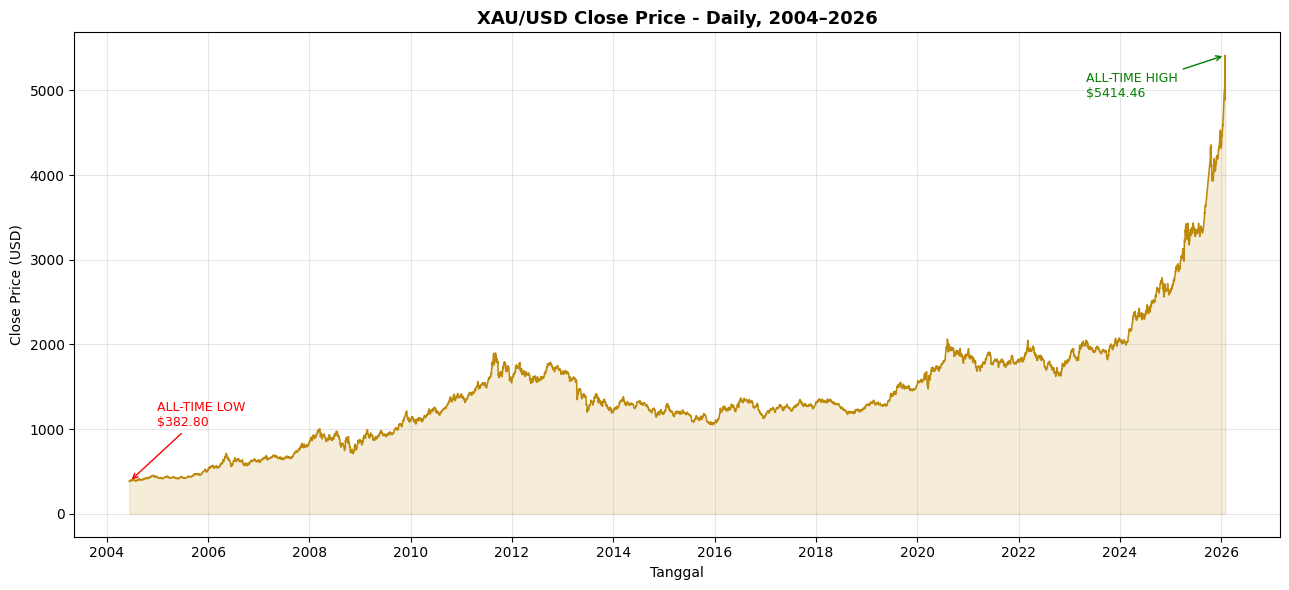

In [53]:
dates_all  = [c.date for c in candles]
closes_all = [c.close for c in candles]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(dates_all, closes_all, color="#BC890A", linewidth=1.1)
ax.fill_between(dates_all, closes_all, alpha=0.15, color="#BC890A")

idx_min = closes_all.index(min(closes_all))
idx_max = closes_all.index(max(closes_all))
ax.annotate(f"ALL-TIME LOW\n${closes_all[idx_min]:.2f}",
            xy=(dates_all[idx_min], closes_all[idx_min]),
            xytext=(20, 40), textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="red"), color="red")
ax.annotate(f"ALL-TIME HIGH\n${closes_all[idx_max]:.2f}",
            xy=(dates_all[idx_max], closes_all[idx_max]),
            xytext=(-100, -30), textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="green"), color="green")

ax.set_title("XAU/USD Close Price - Daily, 2004–2026", fontsize=13, fontweight="bold")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Close Price (USD)")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

NameError: name 'pdf' is not defined

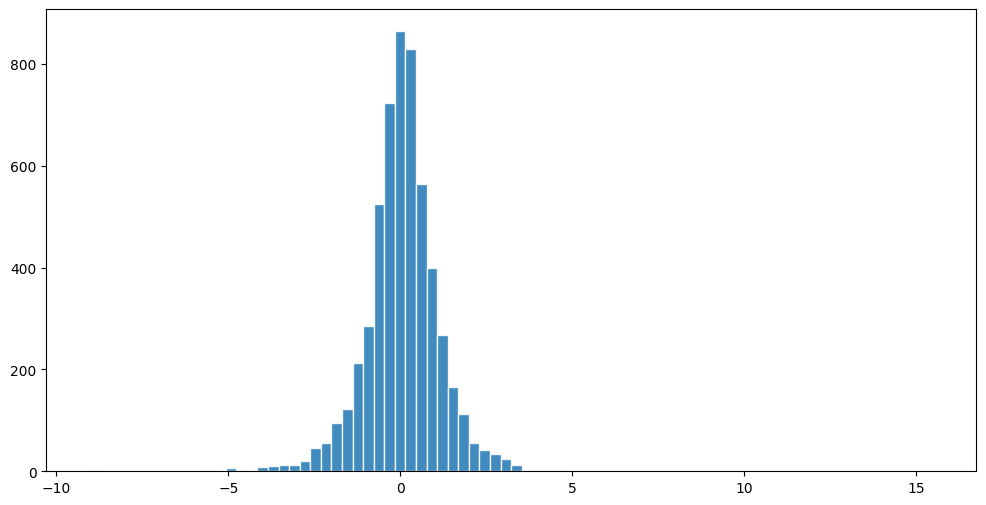

In [54]:
# Daily returns close-to-close
import math
# Hitung daily returns close-to-close (% point)
returns_pct = []
for i in range(1, len(candles)):
    r = (candles[i].close - candles[i-1].close) / candles[i-1].close * 100.0
    returns_pct.append(r)

mean_r = sum(returns_pct) / len(returns_pct)
std_r = pd.Series(returns_pct).std(ddof=1)

fig, ax = plt.subplots(figsize=(12, 6))
n_bins = 80
counts, bin_edges, _ = ax.hist(returns_pct, bins=n_bins, color="#1f77b4",
                                edgecolor="white", alpha=0.85,
                                label=f"Observed (n={len(returns_pct):,})")

x = pd.Series([bin_edges[0] + (bin_edges[-1]-bin_edges[0])*i/200
               for i in range(201)])
bin_width = bin_edges[1] - bin_edges[0]
ax.plot(x, pdf, color="red", linewidth=2,
        label=f"Normal (μ={mean_r:.3f}%, σ={std_r:.3f}%)")

ax.axvline(mean_r, color="darkgreen", linestyle="--", linewidth=1, label=f"Mean")
ax.set_title("Distribusi Daily Returns — XAU/USD (Gold)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Daily Return (%)")
ax.set_ylabel("Frequency")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_xlim(-8, 8)  # crop ekstrem buat readability
plt.tight_layout()
plt.show()
print(f"Mean return harian : {mean_r:+.4f}%")
print(f"Std dev (volatilitas): {std_r:.4f}%")
print(f"Tail terberat       : min={min(returns_pct):.2f}%, max={max(returns_pct):.2f}%")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9588\2047832963.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=[str(y) for y in years_sorted],


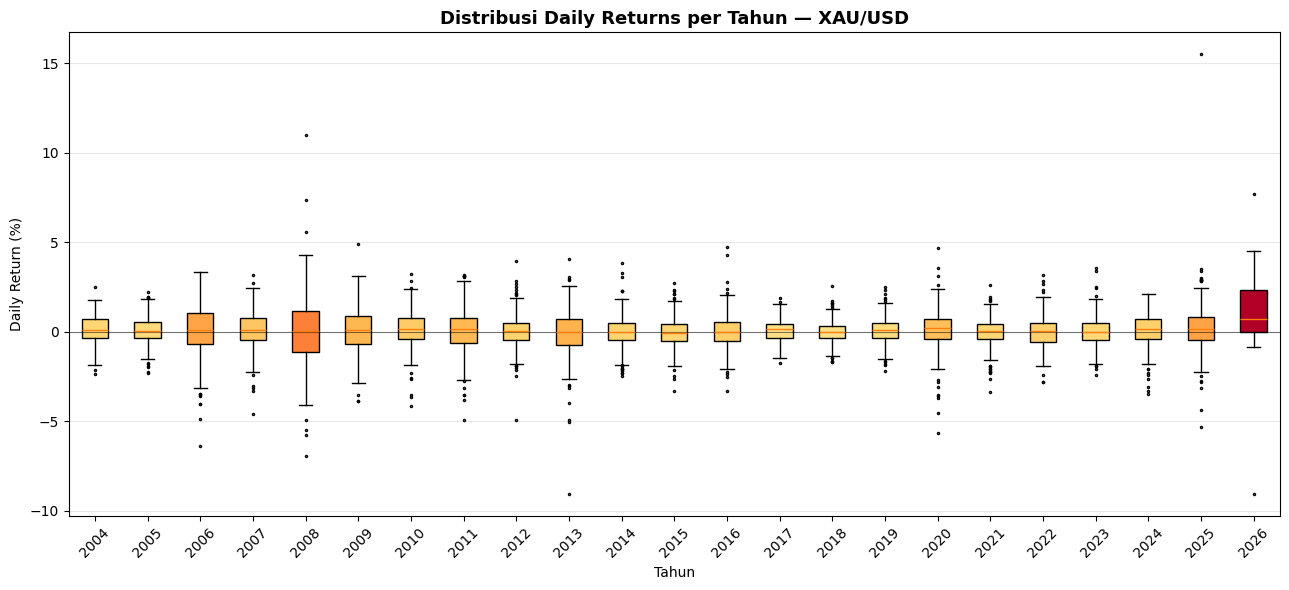

Tahun paling volatile : 2026  (std=3.549%)
Tahun paling tenang  : 2018  (std=0.616%)


In [ ]:
# evolusi volatilitas: tahun mana yang "wild", mana yang tenang.

# group daily returns by year
returns_by_year: dict[int, list[float]] = {}
for i in range(1, len(candles)):
    r = (candles[i].close - candles[i-1].close) / candles[i-1].close * 100.0
    yr = candles[i].date.year
    returns_by_year.setdefault(yr, []).append(r)

years_sorted = sorted(returns_by_year.keys())
data_box = [returns_by_year[y] for y in years_sorted]

fig, ax = plt.subplots(figsize=(13, 6))
bp = ax.boxplot(data_box, labels=[str(y) for y in years_sorted],
                showfliers=True,
                patch_artist=True,
                flierprops=dict(marker=".", color="gray", markersize=3))

# Warna box berdasarkan std (semakin tinggi → semakin merah)
stds = [pd.Series(d).std(ddof=1) for d in data_box]
std_min, std_max = min(stds), max(stds)
for patch, s in zip(bp["boxes"], stds):
    intensity = (s - std_min) / (std_max - std_min)
    patch.set_facecolor(plt.cm.YlOrRd(0.2 + 0.7 * intensity))

ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_title("Distribusi Daily Returns per Tahun — XAU/USD",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Tahun")
ax.set_ylabel("Daily Return (%)")
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

most_vol = years_sorted[stds.index(max(stds))]
least_vol = years_sorted[stds.index(min(stds))]
print(f"Tahun paling volatile : {most_vol}  (std={max(stds):.3f}%)")
print(f"Tahun paling tenang  : {least_vol}  (std={min(stds):.3f}%)")

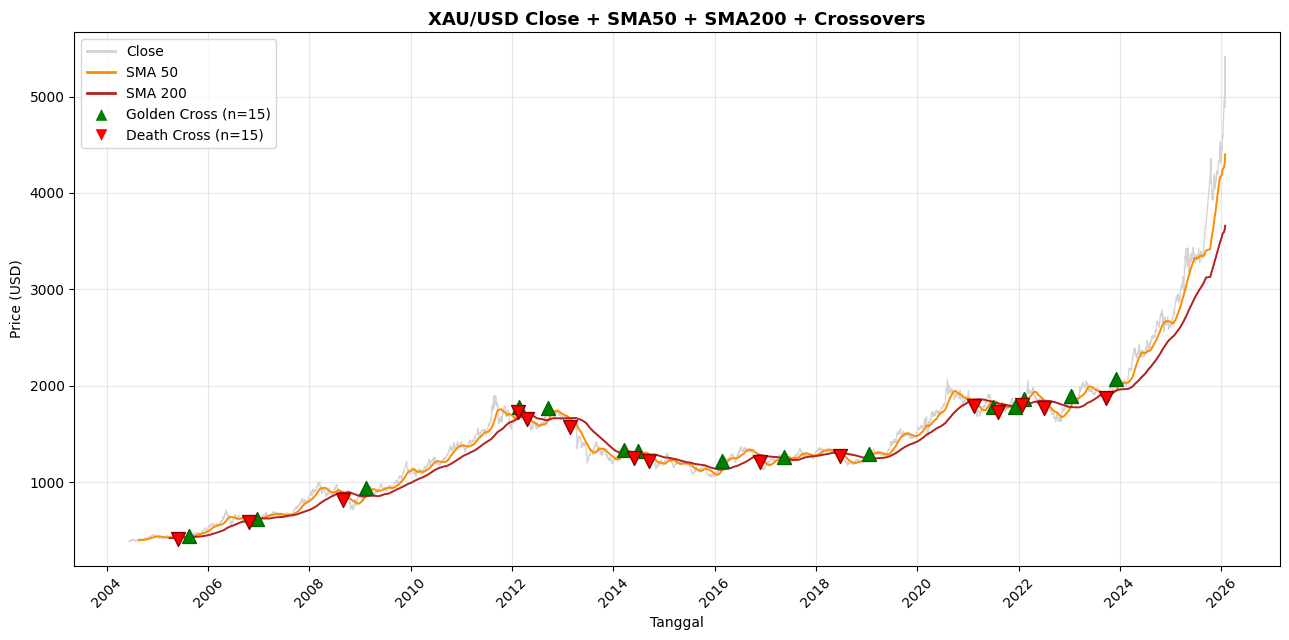

Golden cross : 15 kejadian
Death cross  : 15 kejadian


In [ ]:
# Close + SMA50 + SMA200 + golden/death cross markers

ma = next(a for a in analyzers if isinstance(a, MovingAverageAnalyzer))
sma50  = ma.sma(50)
sma200 = ma.sma(200)
gc_dates = ma.golden_cross_dates()
dc_dates = ma.death_cross_dates()

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.plot(dates_all, closes_all, color="lightgray", linewidth=0.9, label="Close")
ax.plot([d for d,_ in sma50],  [v for _,v in sma50],
        color="#FF8C00", linewidth=1.4, label="SMA 50")
ax.plot([d for d,_ in sma200], [v for _,v in sma200],
        color="#B22222", linewidth=1.4, label="SMA 200")

# Markers untuk crossover - ambil harga close di tanggal cross
date_to_close = dict(zip(dates_all, closes_all))
for d in gc_dates:
    ax.scatter(d, date_to_close[d], marker="^", color="green", s=100,
               edgecolor="darkgreen", zorder=5)
for d in dc_dates:
    ax.scatter(d, date_to_close[d], marker="v", color="red", s=100,
               edgecolor="darkred", zorder=5)

# Legend untuk markers (manual)
from matplotlib.lines import Line2D
legend_items = [
    Line2D([0],[0], color="lightgray", lw=2, label="Close"),
    Line2D([0],[0], color="#FF8C00",   lw=2, label="SMA 50"),
    Line2D([0],[0], color="#B22222",   lw=2, label="SMA 200"),
    Line2D([0],[0], marker="^", color="w", markerfacecolor="green",
           markersize=10, label=f"Golden Cross (n={len(gc_dates)})"),
    Line2D([0],[0], marker="v", color="w", markerfacecolor="red",
           markersize=10, label=f"Death Cross (n={len(dc_dates)})"),
]
ax.legend(handles=legend_items, loc="upper left")

ax.set_title("XAU/USD Close + SMA50 + SMA200 + Crossovers",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Price (USD)")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(f"Golden cross : {len(gc_dates)} kejadian")
print(f"Death cross  : {len(dc_dates)} kejadian")

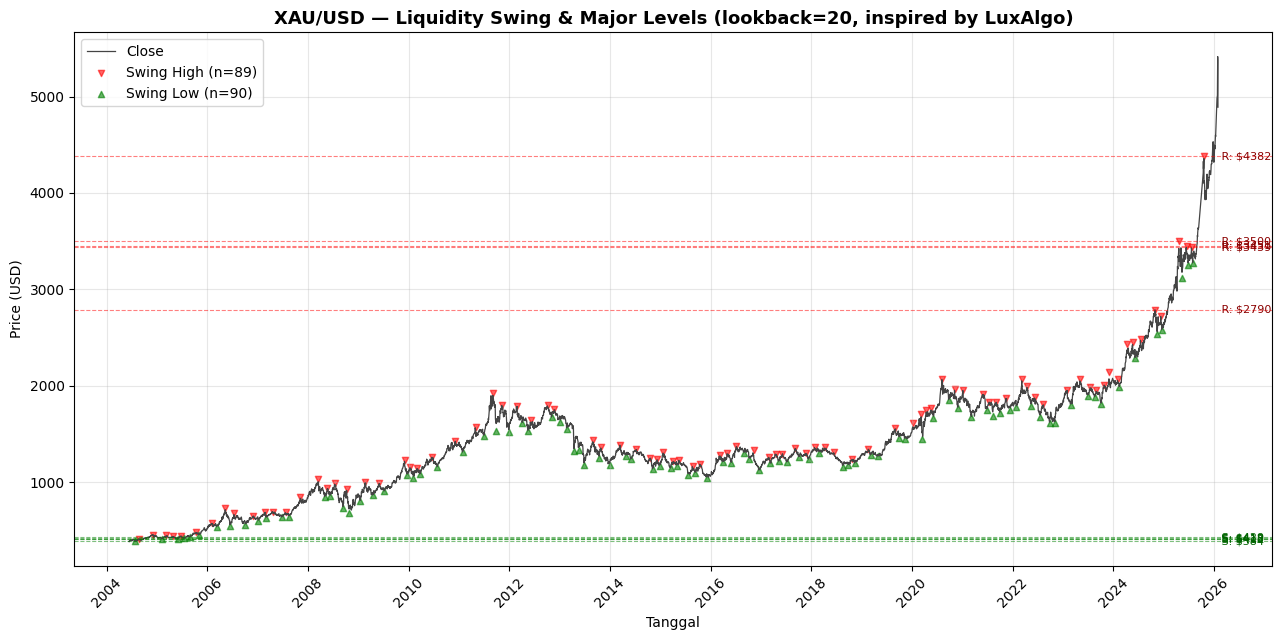

Top resistance: $4,381.58 (2025-10-20)
Top support  : $384.50 (2004-07-28)


In [ ]:
"""Close + Swing High/Low + Top 5 Major Levels 
visualisasi Liquidity Swing"""

liq = next(a for a in analyzers if isinstance(a, LiquiditySwingAnalyzer))
swings_hi = liq.detect_swing_highs()
swings_lo = liq.detect_swing_lows()
levels = liq.find_major_levels(top_n=5)

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.plot(dates_all, closes_all, color="#444444", linewidth=0.9, label="Close")

# Semua swing high/low sebagai dots kecil
ax.scatter([d for d,_ in swings_hi], [p for _,p in swings_hi],
           marker="v", color="red", s=20, alpha=0.6, label=f"Swing High (n={len(swings_hi)})")
ax.scatter([d for d,_ in swings_lo], [p for _,p in swings_lo],
           marker="^", color="green", s=20, alpha=0.6, label=f"Swing Low (n={len(swings_lo)})")

# Top 5 resistance: horizontal dashed lines
for d, p in levels["resistance"]:
    ax.axhline(p, color="red", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.text(dates_all[-1], p, f" R: ${p:.0f}", fontsize=8,
            color="darkred", va="center")
# Top 5 support: horizontal dashed lines
for d, p in levels["support"]:
    ax.axhline(p, color="green", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.text(dates_all[-1], p, f" S: ${p:.0f}", fontsize=8,
            color="darkgreen", va="center")

ax.set_title(f"XAU/USD — Liquidity Swing & Major Levels "
f"(lookback={liq._lookback}, inspired by LuxAlgo)",
fontsize=13, fontweight="bold")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Price (USD)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(f"Top resistance: ${levels['resistance'][0][1]:,.2f} "
f"({levels['resistance'][0][0].date()})")
print(f"Top support  : ${levels['support'][0][1]:,.2f} "
f"({levels['support'][0][0].date()})")